# 08 · Direct Multi-Step Forecasting

## tl;dr

与 07 完全对齐的 **60 个起点 × 每个 horizon 60 点**显示：Direct 在 **24h** 的 MAE 从 1574.94 降到 **1307.71**（改善 16.97%），在 **48h** 改善 5.38%；在 **72h / 168h** 则分别差 0.87% / 13.37%。1h 两种策略逐点相同。Direct 避免递归回填，但**没有稳定的长 horizon MAE 优势**。用同一批 672 个目标小时作辅助检查时，168h Direct 改善 7.85%，72h 仍差 3.41%。工作日早高峰在 24/72/168h 均改善，晚高峰均变差。所有结果仍基于目标小时的 oracle 历史天气。

## Goal · Direct 能否减轻 Recursive 的误差传播？

比较 **HistGradientBoostingRegressor** 的两种策略，固定数据、时间边界、47 列输入语义和 07 的评估起点。核心问题是不同预测提前量下谁的误差更小，而不是把不同时间点或「前 N 小时整体」与「恰好第 N 小时」混作同一指标。

## Context & Methods · 两种多步策略

**Recursive（递归）：**只训练一个 one-step 模型。先预测 $t+1$，把预测值写回历史，再预测 $t+2,t+3,\ldots$。优点是只需一个模型；缺点是错误的 $\hat y_{t+1}$ 会进入之后的 `lag_1`、rolling 等特征，误差可以沿路径传播。

**Direct（直接）：**每个 horizon 单独训练一个模型：$X_t\to y_{t+1}$、$X_t\to y_{t+24}$、$X_t\to y_{t+72}$、$X_t\to y_{t+168}$ 等。预测 168h 时不经过前 167 次预测，因此没有同一形式的递归反馈；但远期信息仍可能不足，每个 horizon 的关系也可能不同。本实验训练 **1、3、6、12、24、48、72、168h** 共 8 个 Direct 模型，模型类和参数均沿用 07。

### 07 与 08 的时间记号

07 的 `Origin` 指**第一段尚未发生的小时** $s$，已知需求截至 $t=s-1\text{h}$。这里把 $t$ 称为 **Forecast Origin（最后已知小时）**，第 $h$ 步目标为 $t+h=s+(h-1)\text{h}$。因此代码从 07 的首个未来小时行取 `lag_1=y(t)`、`lag_24=y(t-23h)`、`lag_168=y(t-167h)`，rolling 也只涵盖截至 $t$ 的 3/6 小时。这与在最后已知时刻构造 $y(t+h)$ 的 `shift(-h)` 标签等价，同时让 h=1 的输入与 07 完全相同。

**特征的两个时间方向：**历史需求特征描述 origin 时已知的系统状态；`target_hour`、`target_day_of_week`、`target_month`、`target_is_weekend` 和天气描述要预测的目标小时。绝不能用目标时间附近的真实需求构造 lag / rolling，例如 72h 预测不能读取 `target-1h` 的真实需求。

### Key Assumptions

- 数据：`data/processed/bikeflow_2024.csv`，2024 年纽约 Citi Bike 小时需求与历史天气。固定测试期为 **2024-10-19 18:00 至 2024-12-31 23:00**。
- 与 07 一样，去掉春季不存在的 `2024-03-10 02:00` 和秋季合并的 `2024-11-03 01:00` 建模行；保留完整小时序列计算历史 lag。60 个有效 07 起点都具有完整 168 小时目标。
- 历史真实天气在目标小时作为 **oracle future weather** 输入；真实部署时只能用天气预报，本实验未评估天气预报误差。
- `target_is_weekend` 会显式构造和审计；它由目标 `day_of_week` 完全决定，07 的 one-hot 已表达该信息，因此不重复加入模型列，以保持相同的 47 维特征语义。
- 主表的每个 horizon 恰好有 60 个与 07 一致的 `(Origin, Step)` 点。由于 07 每天同一时刻起报，不同 h 对应不同目标钟点；跨 horizon 的 MAE 不能全归因于误差传播。另用共同目标小时做辅助诊断。

## Data · 固定数据与时间边界

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams.update({
    "figure.figsize": (12, 5), "font.size": 10,
    "axes.grid": False, "savefig.dpi": 130,
})
COLORS = {
    "Actual": "#25313A", "Recursive HGB": "#24567A",
    "Direct HGB": "#B05A42", "Weekly Seasonal Naive": "#827A56",
}
HORIZONS = (1, 3, 6, 12, 24, 48, 72, 168)
WEATHER_COLUMNS = [
    "temperature_2m", "relative_humidity_2m",
    "precipitation", "wind_speed_10m",
]
DEMAND_COLUMNS = ["lag_1", "lag_24", "lag_168", "rolling_mean_3", "rolling_mean_6"]

project_root = Path.cwd()
if not (project_root / "data" / "processed" / "bikeflow_2024.csv").exists():
    project_root = project_root.parent
data_path = project_root / "data" / "processed" / "bikeflow_2024.csv"
assert data_path.exists(), f"未找到数据：{data_path}"

data = pd.read_csv(data_path, parse_dates=["timestamp"])
data = data.sort_values("timestamp").reset_index(drop=True)
spring_gap = pd.Timestamp("2024-03-10 02:00")
fall_repeat = pd.Timestamp("2024-11-03 01:00")
assert len(data) == 8784
assert not data["timestamp"].duplicated().any()
assert data["timestamp"].diff().iloc[1:].eq(pd.Timedelta(hours=1)).all()
assert data["ride_count"].notna().all()
normal_hour_mask = ~data["timestamp"].isin([spring_gap, fall_repeat])
model_data = data.loc[normal_hour_mask].copy().reset_index(drop=True)
split_index = int(len(model_data) * 0.8)
fixed_test_start = model_data.loc[split_index, "timestamp"]
test_end = model_data["timestamp"].iloc[-1]
assert len(model_data) == 8782 and split_index == 7025
assert fixed_test_start == pd.Timestamp("2024-10-19 18:00")
assert test_end == pd.Timestamp("2024-12-31 23:00")
observed_demand = data.set_index("timestamp")["ride_count"]
print(f"来源：{data_path}")
print(f"完整小时 {len(data):,}；建模小时 {len(model_data):,}；固定测试期 {fixed_test_start} 至 {test_end}")

来源：C:\Users\txy18\Desktop\BikeFlow\data\processed\bikeflow_2024.csv
完整小时 8,784；建模小时 8,782；固定测试期 2024-10-19 18:00:00 至 2024-12-31 23:00:00


### 从 Forecast Origin 的视角构造输入

与 07 相同，`lag_k` 和 rolling 先在完整连续小时序列上计算，再删除 DST 特殊建模行。训练样本只保留目标小时 **严格早于**测试起点的记录。`target_is_weekend` 虽不重复输入模型，仍与目标日历一起保留供审计。

In [2]:
for lag in (1, 24, 168):
    data[f"lag_{lag}"] = data["ride_count"].shift(lag)
prior_demand = data["ride_count"].shift(1)
for window in (3, 6):
    data[f"rolling_mean_{window}"] = prior_demand.rolling(
        window=window, min_periods=window
    ).mean()
model_data[DEMAND_COLUMNS] = data.loc[normal_hour_mask, DEMAND_COLUMNS].to_numpy()
valid_history = model_data[DEMAND_COLUMNS].notna().all(axis=1)

target_calendar = pd.DataFrame({
    "target_hour": pd.Categorical(model_data["timestamp"].dt.hour, categories=range(24)),
    "target_day_of_week": pd.Categorical(model_data["timestamp"].dt.dayofweek, categories=range(7)),
    "target_month": pd.Categorical(model_data["timestamp"].dt.month, categories=range(1, 13)),
    "target_is_weekend": model_data["timestamp"].dt.dayofweek.ge(5).astype(int),
})
calendar_dummies_all = pd.get_dummies(
    target_calendar[["target_hour", "target_day_of_week", "target_month"]],
    drop_first=True, dtype=int,
)
training_calendar_mask = model_data["timestamp"] < fixed_test_start
calendar_columns = calendar_dummies_all.loc[
    training_calendar_mask
].columns[calendar_dummies_all.loc[training_calendar_mask].any(axis=0)].tolist()
assert len(calendar_columns) == 38

target_exogenous = pd.concat([
    calendar_dummies_all[calendar_columns], model_data[WEATHER_COLUMNS]
], axis=1)
target_exogenous.index = pd.DatetimeIndex(model_data["timestamp"])
target_calendar.index = pd.DatetimeIndex(model_data["timestamp"])
origin_demand = model_data[DEMAND_COLUMNS].copy()
origin_demand.index = pd.DatetimeIndex(model_data["timestamp"])
feature_columns = calendar_columns + WEATHER_COLUMNS + DEMAND_COLUMNS
assert len(feature_columns) == 47
assert "ride_count" not in target_exogenous.columns
assert target_exogenous.index.is_unique and origin_demand.index.is_unique
assert target_exogenous.notna().all(axis=None)

def make_direct_matrix(first_future_times, target_times):
    """目标时刻外生信息 + 首个未来小时之前可知的需求状态。"""
    first_future_times = pd.DatetimeIndex(first_future_times)
    target_times = pd.DatetimeIndex(target_times)
    assert len(first_future_times) == len(target_times)
    assert (target_times >= first_future_times).all()
    target_part = target_exogenous.loc[target_times].reset_index(drop=True)
    history_part = origin_demand.loc[first_future_times, DEMAND_COLUMNS].reset_index(drop=True)
    matrix = pd.concat([target_part, history_part], axis=1)[feature_columns]
    assert matrix.notna().all(axis=None)
    assert np.isfinite(matrix.to_numpy()).all()
    return matrix

first_future_candidates = pd.DatetimeIndex(model_data.loc[valid_history, "timestamp"])
training_specs = {}
boundary_rows = []
expected_training_counts = (6857, 6854, 6851, 6845, 6833, 6809, 6785, 6689)
for horizon, expected_count in zip(HORIZONS, expected_training_counts):
    target_times = first_future_candidates + pd.Timedelta(hours=horizon - 1)
    target_exists = target_times.isin(target_exogenous.index)
    train_target = target_times < fixed_test_start
    train_origin = first_future_candidates < fixed_test_start
    use = target_exists & train_target & train_origin
    train_first_future = first_future_candidates[use]
    train_target_times = target_times[use]
    assert len(train_target_times) == expected_count
    assert (train_target_times < fixed_test_start).all()
    assert (train_first_future <= train_target_times).all()
    training_specs[horizon] = (train_first_future, train_target_times)
    boundary_rows.append({
        "Horizon": horizon,
        "Training Pairs": len(train_target_times),
        "Last Training Target": train_target_times.max(),
        "Origin-before-split / target-in-test excluded": int(
            (target_exists & train_origin & ~train_target).sum()
        ),
    })
boundary_table = pd.DataFrame(boundary_rows)
display(boundary_table)

test_valid_times = set(model_data.loc[
    (model_data["timestamp"] >= fixed_test_start) & valid_history, "timestamp"
])
candidate_07_origins = pd.date_range(
    fixed_test_start, test_end - pd.Timedelta(hours=167), freq="24h"
)
first_future_origins_07 = pd.DatetimeIndex([
    origin for origin in candidate_07_origins
    if all(time in test_valid_times for time in pd.date_range(origin, periods=168, freq="h"))
])
assert len(candidate_07_origins) == 67 and len(first_future_origins_07) == 60
print(f"与 07 对齐：{len(first_future_origins_07)} 个有效首个未来小时；每个 horizon 60 个预测点。")

,Horizon,Training Pairs,Last Training Target,Origin-before-split / target-in-test excluded
0,1,6857,2024-10-19 17:00:00,0
1,3,6854,2024-10-19 17:00:00,2
2,6,6851,2024-10-19 17:00:00,5
3,12,6845,2024-10-19 17:00:00,11
4,24,6833,2024-10-19 17:00:00,23
5,48,6809,2024-10-19 17:00:00,47
6,72,6785,2024-10-19 17:00:00,71
7,168,6689,2024-10-19 17:00:00,167


与 07 对齐：60 个有效首个未来小时；每个 horizon 60 个预测点。


## Checks · Leakage Audit

下表对 24/72/168h 各抽 3 个起点。所有 `lag` 与 rolling 的来源都必须 **不晚于 Forecast Origin**；目标需求只作标签，目标日历和目标天气的时间戳必须精确等于 Target Timestamp。特别是 72h 预测所需的 `target-1h` 需求在起报时尚未知，不能进入输入。

In [3]:
audit_rows = []
sample_starts = [first_future_origins_07[i] for i in (0, 29, 59)]
for horizon in (24, 72, 168):
    for first_future in sample_starts:
        forecast_origin = first_future - pd.Timedelta(hours=1)
        target_time = forecast_origin + pd.Timedelta(hours=horizon)
        lag_sources = {lag: first_future - pd.Timedelta(hours=lag) for lag in (1, 24, 168)}
        rolling_sources = {
            window: pd.date_range(
                first_future - pd.Timedelta(hours=window),
                forecast_origin, freq="h"
            ) for window in (3, 6)
        }
        assert all(source <= forecast_origin for source in lag_sources.values())
        assert all((times <= forecast_origin).all() for times in rolling_sources.values())
        for lag, source in lag_sources.items():
            assert origin_demand.loc[first_future, f"lag_{lag}"] == observed_demand.loc[source]
        for window, times in rolling_sources.items():
            assert np.isclose(
                origin_demand.loc[first_future, f"rolling_mean_{window}"],
                observed_demand.loc[times].mean(),
            )
        assert target_time in target_exogenous.index
        assert target_calendar.loc[target_time, "target_is_weekend"] == int(target_time.dayofweek >= 5)
        audit_rows.append({
            "Horizon": horizon,
            "Forecast Origin": forecast_origin,
            "Target Timestamp": target_time,
            "Target Demand (label only)": observed_demand.loc[target_time],
            "lag_1 source": lag_sources[1],
            "lag_24 source": lag_sources[24],
            "lag_168 source": lag_sources[168],
            "rolling_mean_3 window": f"{rolling_sources[3][0]} → {rolling_sources[3][-1]}",
            "rolling_mean_6 window": f"{rolling_sources[6][0]} → {rolling_sources[6][-1]}",
            "future calendar timestamp": target_time,
            "future weather timestamp": target_time,
        })
audit_table = pd.DataFrame(audit_rows)
display(audit_table)
print("Leakage audit 通过：需求特征全部来自 forecast origin 及以前；目标需求未进入输入矩阵。")

,Horizon,Forecast Origin,Target Timestamp,Target Demand (label only),lag_1 source,lag_24 source,lag_168 source,rolling_mean_3 window,rolling_mean_6 window,future calendar timestamp,future weather timestamp
0,24,2024-10-19 17:00:00,2024-10-20 17:00:00,13053,2024-10-19 17:00:00,2024-10-18 18:00:00,2024-10-12 18:00:00,2024-10-19 15:00:00 → 2024-10-19 17:00:00,2024-10-19 12:00:00 → 2024-10-19 17:00:00,2024-10-20 17:00:00,2024-10-20 17:00:00
1,24,2024-11-24 17:00:00,2024-11-25 17:00:00,11801,2024-11-24 17:00:00,2024-11-23 18:00:00,2024-11-17 18:00:00,2024-11-24 15:00:00 → 2024-11-24 17:00:00,2024-11-24 12:00:00 → 2024-11-24 17:00:00,2024-11-25 17:00:00,2024-11-25 17:00:00
2,24,2024-12-24 17:00:00,2024-12-25 17:00:00,1265,2024-12-24 17:00:00,2024-12-23 18:00:00,2024-12-17 18:00:00,2024-12-24 15:00:00 → 2024-12-24 17:00:00,2024-12-24 12:00:00 → 2024-12-24 17:00:00,2024-12-25 17:00:00,2024-12-25 17:00:00
3,72,2024-10-19 17:00:00,2024-10-22 17:00:00,19579,2024-10-19 17:00:00,2024-10-18 18:00:00,2024-10-12 18:00:00,2024-10-19 15:00:00 → 2024-10-19 17:00:00,2024-10-19 12:00:00 → 2024-10-19 17:00:00,2024-10-22 17:00:00,2024-10-22 17:00:00
4,72,2024-11-24 17:00:00,2024-11-27 17:00:00,8631,2024-11-24 17:00:00,2024-11-23 18:00:00,2024-11-17 18:00:00,2024-11-24 15:00:00 → 2024-11-24 17:00:00,2024-11-24 12:00:00 → 2024-11-24 17:00:00,2024-11-27 17:00:00,2024-11-27 17:00:00
5,72,2024-12-24 17:00:00,2024-12-27 17:00:00,4249,2024-12-24 17:00:00,2024-12-23 18:00:00,2024-12-17 18:00:00,2024-12-24 15:00:00 → 2024-12-24 17:00:00,2024-12-24 12:00:00 → 2024-12-24 17:00:00,2024-12-27 17:00:00,2024-12-27 17:00:00
6,168,2024-10-19 17:00:00,2024-10-26 17:00:00,12202,2024-10-19 17:00:00,2024-10-18 18:00:00,2024-10-12 18:00:00,2024-10-19 15:00:00 → 2024-10-19 17:00:00,2024-10-19 12:00:00 → 2024-10-19 17:00:00,2024-10-26 17:00:00,2024-10-26 17:00:00
7,168,2024-11-24 17:00:00,2024-12-01 17:00:00,4204,2024-11-24 17:00:00,2024-11-23 18:00:00,2024-11-17 18:00:00,2024-11-24 15:00:00 → 2024-11-24 17:00:00,2024-11-24 12:00:00 → 2024-11-24 17:00:00,2024-12-01 17:00:00,2024-12-01 17:00:00
8,168,2024-12-24 17:00:00,2024-12-31 17:00:00,5667,2024-12-24 17:00:00,2024-12-23 18:00:00,2024-12-17 18:00:00,2024-12-24 15:00:00 → 2024-12-24 17:00:00,2024-12-24 12:00:00 → 2024-12-24 17:00:00,2024-12-31 17:00:00,2024-12-31 17:00:00


Leakage audit 通过：需求特征全部来自 forecast origin 及以前；目标需求未进入输入矩阵。


## Steps · 训练 8 个 Direct HGB 模型

模型参数与 07 相同。h=1 的训练样本与 07 one-step 完全相同；这里直接将 `direct_models[1]` 用作 Recursive 的 one-step 模型，避免另训一个有细微差别的基线。每个 h 的标签来自目标小时，且其最大训练目标严格早于测试起点。

In [4]:
model_parameters = {
    "max_iter": 240, "learning_rate": 0.07, "max_leaf_nodes": 31,
    "min_samples_leaf": 25, "l2_regularization": 0.1,
    "early_stopping": False, "random_state": 42,
}
direct_models = {}
for horizon in HORIZONS:
    train_first_future, train_target = training_specs[horizon]
    train_matrix = make_direct_matrix(train_first_future, train_target)
    train_label = observed_demand.reindex(train_target).to_numpy()
    assert np.isfinite(train_label).all()
    fitted = HistGradientBoostingRegressor(**model_parameters)
    fitted.fit(train_matrix, train_label)
    direct_models[horizon] = fitted
    print(f"Direct {horizon:>3}h: {len(train_label):,} 组训练样本")
assert len(direct_models) == 8

test_first_future = pd.DatetimeIndex(model_data.loc[
    (model_data["timestamp"] >= fixed_test_start) & valid_history, "timestamp"
])
one_step_matrix = make_direct_matrix(test_first_future, test_first_future)
one_step_actual = observed_demand.reindex(test_first_future).to_numpy()
one_step_prediction = direct_models[1].predict(one_step_matrix)
one_step_mae = mean_absolute_error(one_step_actual, one_step_prediction)
one_step_rmse = np.sqrt(mean_squared_error(one_step_actual, one_step_prediction))
assert len(test_first_future) == 1757
assert abs(one_step_mae - 360.09) < 0.15
assert abs(one_step_rmse - 586.06) < 0.15
print(f"07 one-step 复现：MAE={one_step_mae:.2f}, RMSE={one_step_rmse:.2f}")

Direct   1h: 6,857 组训练样本


Direct   3h: 6,854 组训练样本


Direct   6h: 6,851 组训练样本


Direct  12h: 6,845 组训练样本


Direct  24h: 6,833 组训练样本


Direct  48h: 6,809 组训练样本


Direct  72h: 6,785 组训练样本


Direct 168h: 6,689 组训练样本
07 one-step 复现：MAE=360.09, RMSE=586.06


## Results · 与 07 完全配对的 Rolling-Origin Evaluation

下述 `recursive_predict` 对一组起点同时推进，但**每条轨迹分别持有自己的预测历史**。step 1 以后，若某个 lag / rolling 来源已超过该轨迹的最后已知小时，只能取该轨迹的早期预测值。Weekly Seasonal Naive 始终取目标时刻前 168h 的已知真实需求；在最长 168h 预测中，它仍早于起点。

In [5]:
def recursive_predict(first_future_times, horizon):
    """逐步回填每个 origin 自己的预测；返回 [origin, step] 矩阵。"""
    starts = pd.DatetimeIndex(first_future_times)
    predictions = np.full((len(starts), horizon), np.nan)
    for step in range(1, horizon + 1):
        target_times = starts + pd.Timedelta(hours=step - 1)
        row = target_exogenous.loc[target_times].reset_index(drop=True).copy()
        for lag in (1, 24, 168):
            if step <= lag:
                values = observed_demand.reindex(target_times - pd.Timedelta(hours=lag)).to_numpy()
            else:
                values = predictions[:, step - lag - 1]
            row[f"lag_{lag}"] = values
        for window in (3, 6):
            values = []
            for back in range(1, window + 1):
                if step <= back:
                    values.append(observed_demand.reindex(
                        target_times - pd.Timedelta(hours=back)
                    ).to_numpy())
                else:
                    values.append(predictions[:, step - back - 1])
            row[f"rolling_mean_{window}"] = np.mean(np.column_stack(values), axis=1)
        row = row[feature_columns]
        assert row.notna().all(axis=None)
        predictions[:, step - 1] = direct_models[1].predict(row)
    assert np.isfinite(predictions).all()
    return predictions

recursive_grid = recursive_predict(first_future_origins_07, 168)
panel_parts = []
for row_number, first_future in enumerate(first_future_origins_07):
    target_times = pd.date_range(first_future, periods=168, freq="h")
    weekly_sources = target_times - pd.Timedelta(hours=168)
    assert (weekly_sources < first_future).all()
    panel_parts.append(pd.DataFrame({
        "07 Origin / First Future Hour": first_future,
        "Forecast Origin": first_future - pd.Timedelta(hours=1),
        "Horizon": np.arange(1, 169),
        "Target Timestamp": target_times,
        "Actual": observed_demand.reindex(target_times).to_numpy(),
        "Recursive HGB": recursive_grid[row_number],
        "Weekly Seasonal Naive": observed_demand.reindex(weekly_sources).to_numpy(),
    }))
panel_07 = pd.concat(panel_parts, ignore_index=True)
assert len(panel_07) == 10080
assert not panel_07[["Actual", "Recursive HGB", "Weekly Seasonal Naive"]].isna().any(axis=None)
recursive_full_mae = mean_absolute_error(panel_07["Actual"], panel_07["Recursive HGB"])
recursive_full_rmse = np.sqrt(mean_squared_error(panel_07["Actual"], panel_07["Recursive HGB"]))
naive_full_mae = mean_absolute_error(panel_07["Actual"], panel_07["Weekly Seasonal Naive"])
assert abs(recursive_full_mae - 860.43) < 0.15
assert abs(recursive_full_rmse - 1290.69) < 0.15
assert abs(naive_full_mae - 1269.40) < 0.15
print(f"07 复现：60 × 168 = {len(panel_07):,} 点；Recursive MAE {recursive_full_mae:.2f}, RMSE {recursive_full_rmse:.2f}；Weekly Naive MAE {naive_full_mae:.2f}")

07 复现：60 × 168 = 10,080 点；Recursive MAE 860.43, RMSE 1290.69；Weekly Naive MAE 1269.40


### 恰好提前第 h 小时：MAE 与 RMSE

每一行只取 `Horizon == h` 的 60 对预测，**不是前 h 小时整体 MAE**。`MAE Difference = Direct − Recursive`；`Improvement % = (Recursive − Direct) / Recursive × 100`，因此正数表示 Direct 改善。`Best Method` 只是三者 MAE 最小值的技术标记，具体指标全部保留。

**口径提醒：**这里 h=1 的 60 点都落在每日同一目标钟点；其 MAE 不等于覆盖测试期 1,757 个小时的 one-step MAE 360.09。07 中前 24 小时整段 MAE 708.7 也不等于本表恰好第 24 步的 MAE。

In [6]:
def metrics(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
    }

exact_panel = panel_07.loc[panel_07["Horizon"].isin(HORIZONS)].copy()
exact_panel["Direct HGB"] = np.nan
result_rows = []
for horizon in HORIZONS:
    mask = exact_panel["Horizon"].eq(horizon)
    subset = exact_panel.loc[mask]
    first_future = pd.DatetimeIndex(subset["07 Origin / First Future Hour"])
    target_times = pd.DatetimeIndex(subset["Target Timestamp"])
    direct_prediction = direct_models[horizon].predict(
        make_direct_matrix(first_future, target_times)
    )
    exact_panel.loc[mask, "Direct HGB"] = direct_prediction
    recursive_score = metrics(subset["Actual"], subset["Recursive HGB"])
    direct_score = metrics(subset["Actual"], direct_prediction)
    naive_score = metrics(subset["Actual"], subset["Weekly Seasonal Naive"])
    mae_scores = {
        "Recursive": recursive_score["MAE"],
        "Direct": direct_score["MAE"],
        "Weekly Naive": naive_score["MAE"],
    }
    result_rows.append({
        "Horizon": horizon,
        "Forecast Points": len(subset),
        "Recursive MAE": recursive_score["MAE"],
        "Direct MAE": direct_score["MAE"],
        "Weekly Naive MAE": naive_score["MAE"],
        "Recursive RMSE": recursive_score["RMSE"],
        "Direct RMSE": direct_score["RMSE"],
        "Weekly Naive RMSE": naive_score["RMSE"],
        "Direct − Recursive MAE": direct_score["MAE"] - recursive_score["MAE"],
        "Direct vs Recursive Improvement %": 100 * (
            recursive_score["MAE"] - direct_score["MAE"]
        ) / recursive_score["MAE"],
        "Best Method": " / ".join(
            name for name, value in mae_scores.items()
            if np.isclose(value, min(mae_scores.values()), atol=1e-9)
        ),
    })
results_table = pd.DataFrame(result_rows)
assert results_table["Forecast Points"].eq(60).all()
assert np.allclose(
    exact_panel.loc[exact_panel["Horizon"].eq(1), "Direct HGB"],
    exact_panel.loc[exact_panel["Horizon"].eq(1), "Recursive HGB"],
    atol=1e-9,
)
display(results_table.round(2))
display(Markdown(
    f"RMSE 核对：24h Recursive {results_table.loc[results_table['Horizon'].eq(24), 'Recursive RMSE'].iloc[0]:.1f} → "
    f"Direct {results_table.loc[results_table['Horizon'].eq(24), 'Direct RMSE'].iloc[0]:.1f}；"
    f"72h {results_table.loc[results_table['Horizon'].eq(72), 'Recursive RMSE'].iloc[0]:.1f} → "
    f"{results_table.loc[results_table['Horizon'].eq(72), 'Direct RMSE'].iloc[0]:.1f}；"
    f"168h {results_table.loc[results_table['Horizon'].eq(168), 'Recursive RMSE'].iloc[0]:.1f} → "
    f"{results_table.loc[results_table['Horizon'].eq(168), 'Direct RMSE'].iloc[0]:.1f}。"
))
print("h=1 Direct 与 Recursive 第一步逐点相同：输入、模型和预测点对齐。")

,Horizon,Forecast Points,Recursive MAE,Direct MAE,Weekly Naive MAE,Recursive RMSE,Direct RMSE,Weekly Naive RMSE,Direct − Recursive MAE,Direct vs Recursive Improvement %,Best Method
0,1,60,684.98,684.98,2238.73,1101.62,1101.62,3050.84,0.00,0.00,Recursive / Direct
1,3,60,617.91,669.45,1257.72,821.92,809.65,1683.42,51.54,-8.34,Recursive
2,6,60,494.05,574.55,627.13,605.71,760.93,798.47,80.50,-16.29,Recursive
3,12,60,172.69,273.26,195.85,215.12,374.63,275.14,100.57,-58.24,Recursive
4,24,60,1574.94,1307.71,2810.15,1927.56,1870.60,3622.22,-267.23,16.97,Direct
5,48,60,1584.57,1499.27,2914.83,1936.51,1938.40,3707.17,-85.30,5.38,Direct
6,72,60,1664.98,1679.43,2862.25,2016.70,2153.94,3645.78,14.45,-0.87,Recursive
7,168,60,1696.67,1923.54,2733.23,2085.42,2455.95,3586.41,226.87,-13.37,Recursive


RMSE 核对：24h Recursive 1927.6 → Direct 1870.6；72h 2016.7 → 2153.9；168h 2085.4 → 2456.0。

h=1 Direct 与 Recursive 第一步逐点相同：输入、模型和预测点对齐。


### Horizon-wise MAE 曲线

左侧严格复现 07 的 60 个 origin；右侧使用相同的 672 个**目标小时**。左侧不同 h 落在不同钟点，曲线起伏也反映钟点难度。右侧固定目标时间集合，改变的是提前量及相应的起报时刻，更适合观察远期误差形态；仍不能凭曲线把全部差异因果归于误差传播。

,Horizon,Common Target Points,Recursive MAE,Direct MAE,Weekly Naive MAE,Direct vs Recursive Improvement %
0,1,672,362.02,362.02,1323.7,0.00
1,3,672,713.34,833.70,1323.7,-16.87
2,6,672,815.33,1075.83,1323.7,-31.95
3,12,672,783.46,1011.51,1323.7,-29.11
4,24,672,770.59,764.58,1323.7,0.78
5,48,672,875.56,898.27,1323.7,-2.59
6,72,672,924.29,955.83,1323.7,-3.41
7,168,672,934.93,861.57,1323.7,7.85


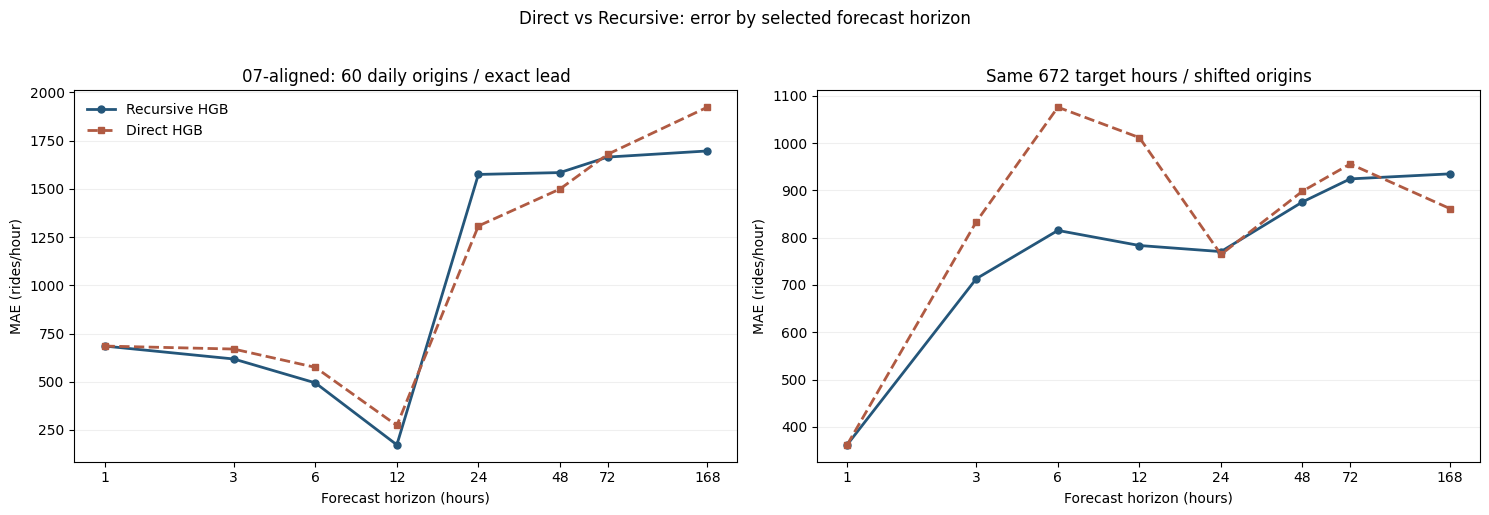

解读：07 对齐主表的 Direct 在 24/48h MAE 较低，72/168h 较高；共同目标小时样本在 72h 改善 -3.4%，168h 改善 +7.8%。Direct 消除了递归回填机制，但本实验没有一致的远期误差优势。


In [7]:
common_target_times = pd.date_range(
    "2024-11-18 00:00", "2024-12-15 23:00", freq="h"
)
assert len(common_target_times) == 672
assert common_target_times.isin(target_exogenous.index).all()
assert common_target_times.min() - pd.Timedelta(hours=167) >= fixed_test_start
common_panels = {}
common_rows = []
for horizon in HORIZONS:
    first_future = common_target_times - pd.Timedelta(hours=horizon - 1)
    recursive_prediction = recursive_predict(first_future, horizon)[:, -1]
    direct_prediction = direct_models[horizon].predict(
        make_direct_matrix(first_future, common_target_times)
    )
    actual = observed_demand.reindex(common_target_times).to_numpy()
    weekly = observed_demand.reindex(common_target_times - pd.Timedelta(hours=168)).to_numpy()
    assert np.isfinite(actual).all() and np.isfinite(weekly).all()
    common_panels[horizon] = pd.DataFrame({
        "Target Timestamp": common_target_times,
        "Forecast Origin": first_future - pd.Timedelta(hours=1),
        "Actual": actual,
        "Recursive HGB": recursive_prediction,
        "Direct HGB": direct_prediction,
        "Weekly Seasonal Naive": weekly,
    })
    scores = {method: metrics(actual, common_panels[horizon][method])
              for method in ("Recursive HGB", "Direct HGB", "Weekly Seasonal Naive")}
    common_rows.append({
        "Horizon": horizon, "Common Target Points": len(actual),
        "Recursive MAE": scores["Recursive HGB"]["MAE"],
        "Direct MAE": scores["Direct HGB"]["MAE"],
        "Weekly Naive MAE": scores["Weekly Seasonal Naive"]["MAE"],
        "Direct vs Recursive Improvement %": 100 * (
            scores["Recursive HGB"]["MAE"] - scores["Direct HGB"]["MAE"]
        ) / scores["Recursive HGB"]["MAE"],
    })
common_target_table = pd.DataFrame(common_rows)
assert np.allclose(common_panels[1]["Recursive HGB"], common_panels[1]["Direct HGB"])
display(common_target_table.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)
for ax, table, title in (
    (axes[0], results_table, "07-aligned: 60 daily origins / exact lead"),
    (axes[1], common_target_table, "Same 672 target hours / shifted origins"),
):
    for column, name, linestyle, marker in (
        ("Recursive MAE", "Recursive HGB", "-", "o"),
        ("Direct MAE", "Direct HGB", "--", "s"),
    ):
        ax.plot(table["Horizon"], table[column], label=name,
                color=COLORS[name], linestyle=linestyle, marker=marker,
                linewidth=2, markersize=5)
    ax.set_xscale("log", base=2)
    ax.set(xlabel="Forecast horizon (hours)", ylabel="MAE (rides/hour)", title=title,
           xticks=list(HORIZONS))
    ax.set_xticklabels([str(horizon) for horizon in HORIZONS])
    ax.grid(axis="y", alpha=0.2)
axes[0].legend(frameon=False)
fig.suptitle("Direct vs Recursive: error by selected forecast horizon", y=1.02)
fig.tight_layout()
plt.show()
print(
    "解读：07 对齐主表的 Direct 在 24/48h MAE 较低，72/168h 较高；"
    f"共同目标小时样本在 72h 改善 {common_target_table.loc[common_target_table['Horizon'].eq(72), 'Direct vs Recursive Improvement %'].iloc[0]:+.1f}%，"
    f"168h 改善 {common_target_table.loc[common_target_table['Horizon'].eq(168), 'Direct vs Recursive Improvement %'].iloc[0]:+.1f}%。"
    "Direct 消除了递归回填机制，但本实验没有一致的远期误差优势。"
)

### 24h / 72h / 168h 的一周可视化

固定 **2024-11-18 至 11-24** 这一周的目标小时，三个 horizon 都使用同一组 168 个目标时间。每一个画出的点由它自己更早的 hourly forecast origin 产生，**不是**从一个起点连续预测 168h 的单条 Direct 路径。灰色表示周末；工作日 07–09 与 16–19 的波峰可以直接观察。

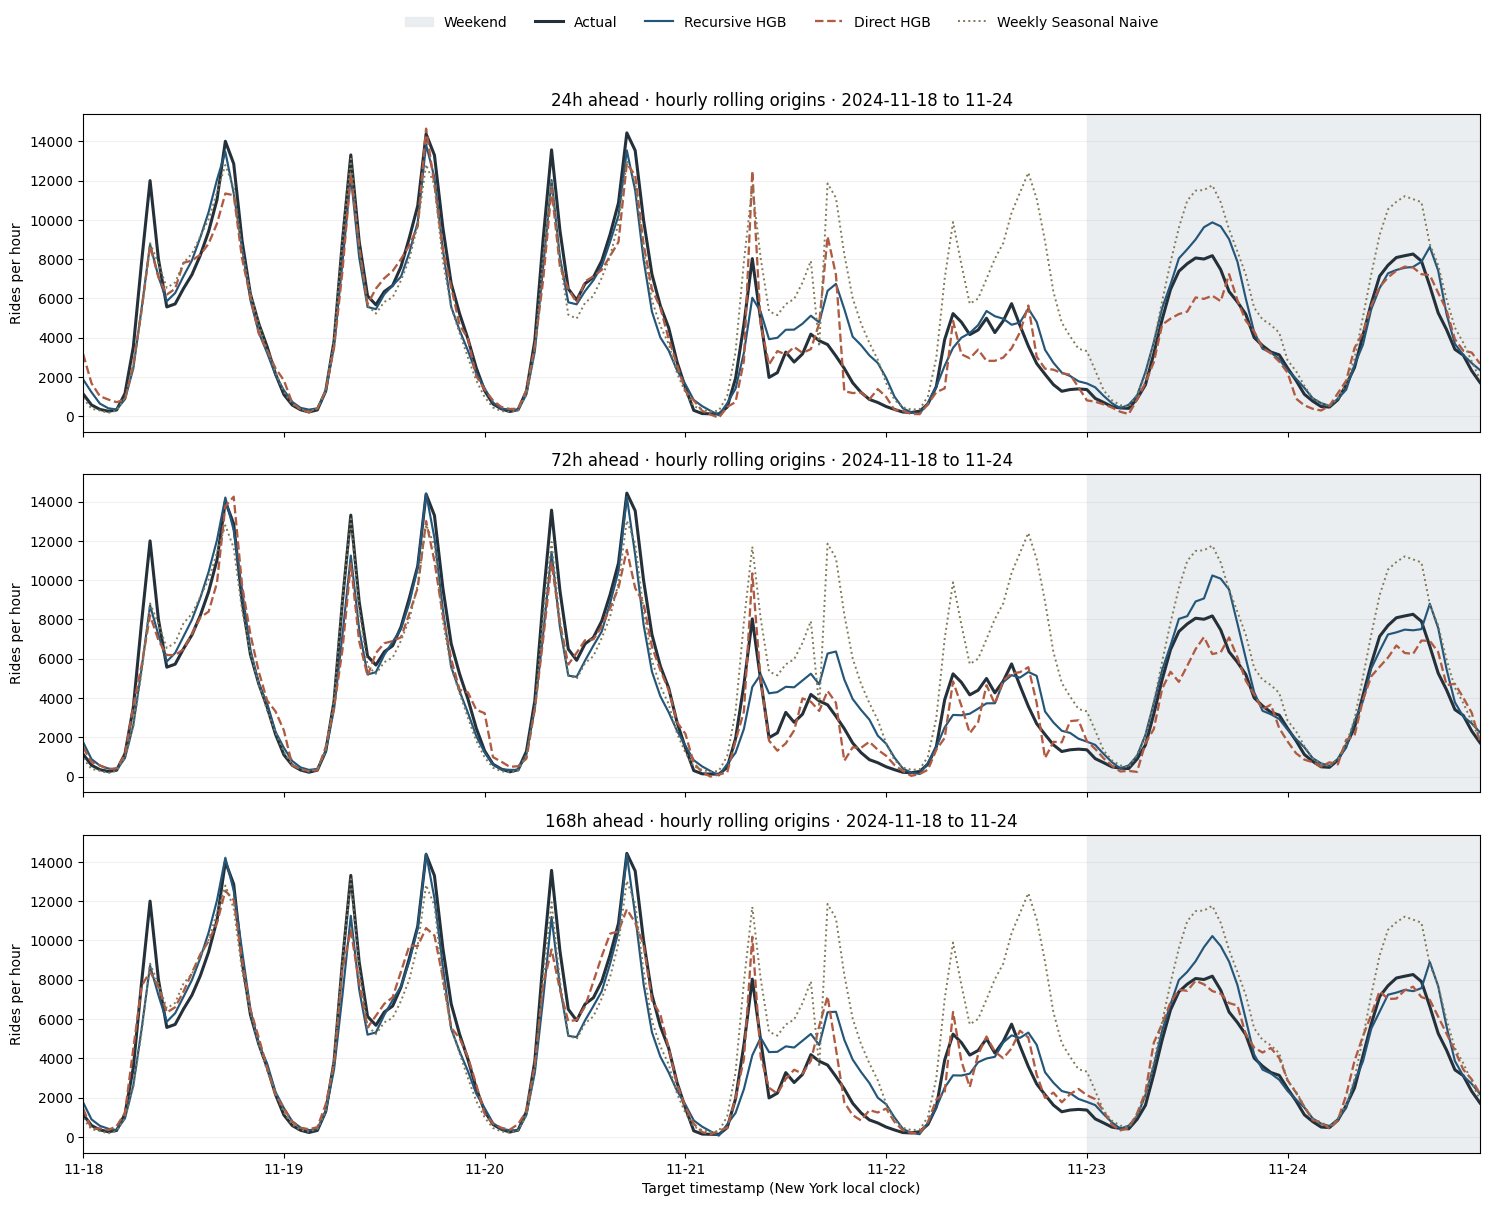

In [8]:
selected_horizons = (24, 72, 168)
week_start = pd.Timestamp("2024-11-18 00:00")
week_end = pd.Timestamp("2024-11-24 23:00")
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True, sharey=True)
for ax, horizon in zip(axes, selected_horizons):
    week = common_panels[horizon].loc[
        common_panels[horizon]["Target Timestamp"].between(week_start, week_end)
    ]
    assert len(week) == 168
    ax.axvspan(pd.Timestamp("2024-11-23"), pd.Timestamp("2024-11-25"),
               color="#E9EDF0", alpha=0.9, label="Weekend")
    for column, linestyle, width in (
        ("Actual", "-", 2.2),
        ("Recursive HGB", "-", 1.55),
        ("Direct HGB", "--", 1.65),
        ("Weekly Seasonal Naive", ":", 1.4),
    ):
        ax.plot(week["Target Timestamp"], week[column], label=column,
                color=COLORS[column], linestyle=linestyle, linewidth=width)
    ax.set(title=f"{horizon}h ahead · hourly rolling origins · 2024-11-18 to 11-24",
           ylabel="Rides per hour", xlim=(week_start, week_end))
    ax.grid(axis="y", alpha=0.18)
axes[0].legend(frameon=False, ncol=5, loc="upper center", bbox_to_anchor=(0.5, 1.35))
axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=1))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
axes[-1].set_xlabel("Target timestamp (New York local clock)")
fig.tight_layout()
plt.show()

### Bias Analysis · 正误差表示平均低估

`Mean Error = Actual − Prediction`。本表继续使用主评估的每个 horizon **60 个严格配对点**，因此可直接比较两种策略在同一批预测目标上的偏差方向。

In [9]:
bias_rows = []
for horizon in selected_horizons:
    subset = exact_panel.loc[exact_panel["Horizon"].eq(horizon)]
    for method in ("Recursive HGB", "Direct HGB"):
        residual = subset["Actual"] - subset[method]
        bias_rows.append({
            "Horizon": horizon, "Forecast Points": len(subset), "Method": method,
            "MAE": residual.abs().mean(), "Mean Error (Actual − Prediction)": residual.mean(),
        })
bias_table = pd.DataFrame(bias_rows)
display(bias_table.round(2))

,Horizon,Forecast Points,Method,MAE,Mean Error (Actual − Prediction)
0,24,60,Recursive HGB,1574.94,-86.88
1,24,60,Direct HGB,1307.71,243.51
2,72,60,Recursive HGB,1664.98,-262.45
3,72,60,Direct HGB,1679.43,394.02
4,168,60,Recursive HGB,1696.67,-402.68
5,168,60,Direct HGB,1923.54,82.56


### Peak Hour Analysis · 同一批目标小时

07 的 60 个日频起点在每个固定 h 下只落在**一个钟点**，不能覆盖早高峰。因此这里从上面的 672 个共同目标小时中筛出工作日 **07–09** 和 **16–19**，在每个 h 下对相同目标时间评分。四周共有 20 个工作日：早高峰每 horizon 60 点，晚高峰每 horizon 80 点。此辅助样本与主表不同，**不与主表的 MAE 混用**。

In [10]:
peak_rows = []
for horizon in selected_horizons:
    frame = common_panels[horizon].copy()
    target_clock = frame["Target Timestamp"]
    weekday = target_clock.dt.dayofweek < 5
    for period, hours in (("Morning 07–09", (7, 8, 9)),
                          ("Evening 16–19", (16, 17, 18, 19))):
        subset = frame.loc[weekday & target_clock.dt.hour.isin(hours)]
        recursive_residual = subset["Actual"] - subset["Recursive HGB"]
        direct_residual = subset["Actual"] - subset["Direct HGB"]
        recursive_mae = recursive_residual.abs().mean()
        direct_mae = direct_residual.abs().mean()
        peak_rows.append({
            "Horizon": horizon, "Peak Period": period,
            "Forecast Points": len(subset),
            "Recursive MAE": recursive_mae, "Direct MAE": direct_mae,
            "Recursive Mean Error": recursive_residual.mean(),
            "Direct Mean Error": direct_residual.mean(),
            "Direct Improvement %": 100 * (recursive_mae - direct_mae) / recursive_mae,
        })
peak_table = pd.DataFrame(peak_rows)
assert peak_table["Forecast Points"].tolist() == [60, 80] * 3
display(peak_table.round(2))

,Horizon,Peak Period,Forecast Points,Recursive MAE,Direct MAE,Recursive Mean Error,Direct Mean Error,Direct Improvement %
0,24,Morning 07–09,60,1853.64,1474.88,533.89,577.43,20.43
1,24,Evening 16–19,80,1450.00,1534.83,95.47,333.61,-5.85
2,72,Morning 07–09,60,2121.28,1960.13,690.87,812.07,7.60
3,72,Evening 16–19,80,1547.03,1979.29,38.01,730.85,-27.94
4,168,Morning 07–09,60,2125.60,1929.73,699.29,492.02,9.21
5,168,Evening 16–19,80,1553.90,1827.58,-38.00,473.66,-17.61


### Optional · 单一起点的稀疏 Direct 预测

这 8 个目标来自同一 forecast origin，但由 8 个独立模型给出。它们不是连续的 168 小时预测路径；相邻 horizon 模型可能产生不连续的预测，这也是 Direct 的代价之一。

In [11]:
illustration_first_future = pd.Timestamp("2024-11-18 00:00")
consistency_rows = []
for horizon in HORIZONS:
    target_time = illustration_first_future + pd.Timedelta(hours=horizon - 1)
    prediction = direct_models[horizon].predict(
        make_direct_matrix([illustration_first_future], [target_time])
    )[0]
    consistency_rows.append({
        "Horizon": horizon, "Forecast Origin": illustration_first_future - pd.Timedelta(hours=1),
        "Target Timestamp": target_time, "Actual": observed_demand.loc[target_time],
        "Direct Prediction": prediction,
    })
consistency_table = pd.DataFrame(consistency_rows)
consistency_preview = consistency_table.copy()
consistency_preview["Direct Prediction"] = consistency_preview["Direct Prediction"].round(1)
display(consistency_preview)

,Horizon,Forecast Origin,Target Timestamp,Actual,Direct Prediction
0,1,2024-11-17 23:00:00,2024-11-18 00:00:00,1140,1312.4
1,3,2024-11-17 23:00:00,2024-11-18 02:00:00,354,703.6
2,6,2024-11-17 23:00:00,2024-11-18 05:00:00,1162,1343.5
3,12,2024-11-17 23:00:00,2024-11-18 11:00:00,5723,4587.6
4,24,2024-11-17 23:00:00,2024-11-18 23:00:00,2152,2444.9
5,48,2024-11-17 23:00:00,2024-11-19 23:00:00,2463,2588.5
6,72,2024-11-17 23:00:00,2024-11-20 23:00:00,2771,2765.6
7,168,2024-11-17 23:00:00,2024-11-24 23:00:00,1724,2187.3


## Takeaways · 策略代价与下一阶段

Direct **不是无条件优于** Recursive：

1. 每个 horizon 需要单独训练与维护模型；若覆盖 168 个小时，模型数量可能大幅增加。
2. 各模型独立输出，预测路径不保证连续。例如 24h 预测 8000、25h 预测 6000 可能不符合平滑的实际序列。
3. Direct 不自动利用前一步预测带来的新状态；Recursive 则可以更新 lag / rolling，但也会传播错误。
4. 越远的 horizon，本来就越缺少可预测信息；没有递归反馈也不会消除所有远期误差。
5. 两种模型此处都使用目标小时的真实历史天气（oracle）。真实部署只能换成当时可获得的天气预报，性能需重新评估。

后续可研究 **Multi-Output Forecasting**，同时学习多个 horizon 并检查路径一致性；更远的方向还有 Seq2Seq、LSTM / GRU、Temporal Convolution、Transformer-based Forecasting。本 Notebook 不实现这些模型。

## Final Summary · 由实际运行结果生成

In [12]:
lookup = results_table.set_index("Horizon")
common_lookup = common_target_table.set_index("Horizon")
peak_lookup = peak_table.set_index(["Horizon", "Peak Period"])
bias_lookup = bias_table.set_index(["Horizon", "Method"])

def winner(horizon):
    row = lookup.loc[horizon]
    if np.isclose(row["Direct MAE"], row["Recursive MAE"], atol=1e-8):
        return "Direct 与 Recursive 相同"
    return "Direct" if row["Direct MAE"] < row["Recursive MAE"] else "Recursive"

direct_better = [h for h in HORIZONS if lookup.loc[h, "Direct MAE"] < lookup.loc[h, "Recursive MAE"] - 1e-8]
recursive_better = [h for h in HORIZONS if lookup.loc[h, "Recursive MAE"] < lookup.loc[h, "Direct MAE"] - 1e-8]
peak_lines = []
for horizon in selected_horizons:
    for period in ("Morning 07–09", "Evening 16–19"):
        row = peak_lookup.loc[(horizon, period)]
        peak_lines.append(
            f"{horizon}h {period}: {row['Recursive MAE']:.1f} → {row['Direct MAE']:.1f} "
            f"({row['Direct Improvement %']:+.1f}%)"
        )
bias_lines = []
for horizon in selected_horizons:
    recursive_bias = bias_lookup.loc[(horizon, "Recursive HGB"), "Mean Error (Actual − Prediction)"]
    direct_bias = bias_lookup.loc[(horizon, "Direct HGB"), "Mean Error (Actual − Prediction)"]
    bias_lines.append(f"{horizon}h: Recursive {recursive_bias:+.1f}, Direct {direct_bias:+.1f}")

summary = f'''
1. **原理：**Direct 对每个 h 直接拟合未来目标；无需将前一步预测反复写进 lag / rolling。Recursive 只需一个模型，但预测反馈会累积。
2. **1h：**Recursive MAE {lookup.loc[1, 'Recursive MAE']:.2f}，Direct {lookup.loc[1, 'Direct MAE']:.2f}；逐点相同，证明起点、输入和评估对齐。
3. **24h：**Recursive {lookup.loc[24, 'Recursive MAE']:.2f}，Direct {lookup.loc[24, 'Direct MAE']:.2f}；{winner(24)} 更好，Direct 相对变化 {lookup.loc[24, 'Direct vs Recursive Improvement %']:+.1f}%。
4. **72h：**Recursive {lookup.loc[72, 'Recursive MAE']:.2f}，Direct {lookup.loc[72, 'Direct MAE']:.2f}；{winner(72)} 更好，Direct 相对变化 {lookup.loc[72, 'Direct vs Recursive Improvement %']:+.1f}%。
5. **168h：**Recursive {lookup.loc[168, 'Recursive MAE']:.2f}，Direct {lookup.loc[168, 'Direct MAE']:.2f}；{winner(168)} 更好，Direct 相对变化 {lookup.loc[168, 'Direct vs Recursive Improvement %']:+.1f}%。
6. **方法胜负：**Direct MAE 较低的 horizons：{', '.join(map(str, direct_better)) or '无'}；Recursive MAE 较低：{', '.join(map(str, recursive_better)) or '无'}。1h 为相同模型与相同输入。
7. **传播迹象：**07 对齐主表的 72h / 168h Direct 均较差；共同目标小时的 672 点中，72h Direct 相对变化 {common_lookup.loc[72, 'Direct vs Recursive Improvement %']:+.1f}%，168h {common_lookup.loc[168, 'Direct vs Recursive Improvement %']:+.1f}%。Direct 消除了递归回填机制，但本实验**没有一致的远期 MAE 优势**；观测差异不能全归因于误差传播。
8. **高峰：**{'；'.join(peak_lines)}。这里使用四周同一批目标小时，不等同于主表的 60 点。
9. **系统偏差：**Mean Error = Actual − Prediction，正数表示低估。{'；'.join(bias_lines)}；详见 Bias 表。
10. **Direct 的代价：**8 个独立模型、模型数随 horizon 增长、预测路径可能不连续、不自动利用前一步预测的新状态。
11. **天气限制：**目标小时使用真实历史天气（oracle）；天气预报输入可能改变结论，本实验不是完整生产级未来预测。
12. **下一步：**值得用相同起点、目标时间与天气假设测试 Multi-Output，检验是否能兼顾远期误差与路径一致性；无需在此阶段直接转向深度学习。
'''
display(Markdown(summary))


1. **原理：**Direct 对每个 h 直接拟合未来目标；无需将前一步预测反复写进 lag / rolling。Recursive 只需一个模型，但预测反馈会累积。
2. **1h：**Recursive MAE 684.98，Direct 684.98；逐点相同，证明起点、输入和评估对齐。
3. **24h：**Recursive 1574.94，Direct 1307.71；Direct 更好，Direct 相对变化 +17.0%。
4. **72h：**Recursive 1664.98，Direct 1679.43；Recursive 更好，Direct 相对变化 -0.9%。
5. **168h：**Recursive 1696.67，Direct 1923.54；Recursive 更好，Direct 相对变化 -13.4%。
6. **方法胜负：**Direct MAE 较低的 horizons：24, 48；Recursive MAE 较低：3, 6, 12, 72, 168。1h 为相同模型与相同输入。
7. **传播迹象：**07 对齐主表的 72h / 168h Direct 均较差；共同目标小时的 672 点中，72h Direct 相对变化 -3.4%，168h +7.8%。Direct 消除了递归回填机制，但本实验**没有一致的远期 MAE 优势**；观测差异不能全归因于误差传播。
8. **高峰：**24h Morning 07–09: 1853.6 → 1474.9 (+20.4%)；24h Evening 16–19: 1450.0 → 1534.8 (-5.9%)；72h Morning 07–09: 2121.3 → 1960.1 (+7.6%)；72h Evening 16–19: 1547.0 → 1979.3 (-27.9%)；168h Morning 07–09: 2125.6 → 1929.7 (+9.2%)；168h Evening 16–19: 1553.9 → 1827.6 (-17.6%)。这里使用四周同一批目标小时，不等同于主表的 60 点。
9. **系统偏差：**Mean Error = Actual − Prediction，正数表示低估。24h: Recursive -86.9, Direct +243.5；72h: Recursive -262.5, Direct +394.0；168h: Recursive -402.7, Direct +82.6；详见 Bias 表。
10. **Direct 的代价：**8 个独立模型、模型数随 horizon 增长、预测路径可能不连续、不自动利用前一步预测的新状态。
11. **天气限制：**目标小时使用真实历史天气（oracle）；天气预报输入可能改变结论，本实验不是完整生产级未来预测。
12. **下一步：**值得用相同起点、目标时间与天气假设测试 Multi-Output，检验是否能兼顾远期误差与路径一致性；无需在此阶段直接转向深度学习。
